# Proyecto 1 
 Juan Camilo Gómez-202220238
 
 Jerónimo Rueda-202223775

### Librerias


In [77]:
   
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  

## Datos

In [78]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%d/%m/%Y",
    errors="coerce"
)
df["estu_fechanacimiento"].isna().sum()

#df["estu_fechanacimiento"].describe()

#df.loc[641382, ["estu_fechanacimiento","periodo"]]

df["año"]=df["periodo"].astype(str).str[:4]



ti_menoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 17).astype(str),format="%d/%m/%Y")

cc_mayoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 18).astype(str),format="%d/%m/%Y")

reemplazofechanac = df["estu_fechanacimiento"].isna() | (df["estu_fechanacimiento"].dt.year == 1900)

df.loc[reemplazofechanac, "estu_fechanacimiento"] = np.where(
    df.loc[reemplazofechanac, "estu_tipodocumento"].eq("TI"),
    ti_menoresedad.loc[reemplazofechanac],
    cc_mayoresedad.loc[reemplazofechanac]
)
#df.loc[df["estu_fechanacimiento"].isna(), "estu_fechanacimiento"] = np.where(df["estu_tipodocumento"] == "TI",ti_menoresedad,cc_mayoresedad)
#df[df["estu_fechanacimiento"].isna()][["estu_fechanacimiento","periodo","estu_tipodocumento"]][["periodo","estu_tipodocumento"]].value_counts() 

df=df[df["año"].astype(int)>2014]

#print(df["estu_fechanacimiento"].sort_values().head(50))
#print(df["estu_fechanacimiento"].sort_values().tail(10))

reemplazos = {
    "CALIMA": "CALIMA EL DARIEN",
    "CALIMA (DARIEN)": "CALIMA EL DARIEN",
    "BUGA": "GUADALAJARA DE BUGA",
    "JAMUNDÍ": "JAMUNDI",
    "ALCALÁ": "ALCALA",
    "ANDALUCÍA": "ANDALUCIA",
    "BOLÍVAR": "BOLIVAR",
    "EL ÁGUILA": "EL AGUILA",
    "GUACARÍ": "GUACARI",
    "RIOFRÍO": "RIOFRIO",
    "LA UNIÓN": "LA UNION",
    "TULUÁ": "TULUA"
}

df["cole_mcpio_ubicacion"] = df["cole_mcpio_ubicacion"].replace(reemplazos)
print(df["cole_mcpio_ubicacion"].unique().tolist())

['CALI', 'GUADALAJARA DE BUGA', 'JAMUNDI', 'RESTREPO', 'BUENAVENTURA', 'CALIMA EL DARIEN', 'YUMBO', 'CANDELARIA', 'TULUA', 'PALMIRA', 'CARTAGO', 'BOLIVAR', 'DAGUA', 'EL CERRITO', 'ALCALA', 'ROLDANILLO', 'SAN PEDRO', 'LA CUMBRE', 'CAICEDONIA', 'FLORIDA', 'ZARZAL', 'OBANDO', 'TRUJILLO', 'ANDALUCIA', 'VIJES', 'RIOFRIO', 'VERSALLES', 'GINEBRA', 'PRADERA', 'LA VICTORIA', 'BUGALAGRANDE', 'SEVILLA', 'GUACARI', 'ANSERMANUEVO', 'LA UNION', 'EL DOVIO', 'TORO', 'ARGELIA', 'YOTOCO', 'ULLOA', 'EL AGUILA', 'EL CAIRO']


### Atributos

In [79]:
df.shape
print(df["estrato_num"].value_counts())
print(df["fami_estratovivienda"].value_counts())

estrato_num
2.0    87279
1.0    66415
3.0    54964
4.0    16747
5.0     9981
6.0     4515
0.0     2589
Name: count, dtype: int64
fami_estratovivienda
Estrato 2      87279
Estrato 1      66415
Estrato 3      54964
Estrato 4      16747
Estrato 5       9981
Estrato 6       4515
Sin Estrato     2589
Name: count, dtype: int64


# Descripción Breve Estadística

In [80]:
df.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_fechanacimiento,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num
count,254015.000000,2.539480e+05,2.540150e+05,254015.0,254015.000000,254015.000000,253987.000000,253987.000000,253743.000000,253743.000000,254015,253917.00000,254015.000000,254015.000000,254015.000000,254015.000000,254015.000000,242490.000000
mean,20181.644021,2.685301e+11,2.691913e+11,76.0,76200.756975,152570.702486,75.815439,76006.893345,75.808732,76007.118001,2000-06-15 11:29:33.632265856,52.12968,51.250765,50.260615,51.338437,53.505324,258.151491,2.267508
min,20151.000000,1.760010e+11,1.760010e+11,76.0,76001.000000,16659.000000,5.000000,5001.000000,5.000000,5001.000000,1910-03-03 00:00:00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.761090e+11,1.761090e+11,76.0,76001.000000,24430.000000,76.000000,76001.000000,76.000000,76001.000000,1998-10-07 00:00:00,43.00000,42.000000,41.000000,43.000000,46.000000,220.000000,1.000000
50%,20172.000000,1.768921e+11,1.768950e+11,76.0,76001.000000,95083.000000,76.000000,76001.000000,76.000000,76001.000000,2000-05-24 00:00:00,50.00000,51.000000,50.000000,51.000000,53.000000,255.000000,2.000000
75%,20194.000000,3.760010e+11,3.760010e+11,76.0,76364.000000,144931.000000,76.000000,76306.000000,76.000000,76364.000000,2002-11-25 00:00:00,59.00000,59.000000,59.000000,59.000000,61.000000,293.000000,3.000000
max,20224.000000,5.376109e+11,5.376110e+11,76.0,76895.000000,806752.000000,99.000000,99524.000000,95.000000,95001.000000,2022-03-05 00:00:00,100.00000,100.000000,100.000000,100.000000,100.000000,495.000000,6.000000
std,25.287858,9.882207e+10,9.891760e+10,0.0,287.206300,198930.462455,3.265251,3278.166802,3.326545,3336.116728,NaN,13.18046,12.301105,11.962517,10.885795,10.305067,51.656128,1.190088


In [81]:
df.info()
colegios=df.groupby("cole_cod_dane_sede").describe()


<class 'pandas.core.frame.DataFrame'>
Index: 254015 entries, 0 to 642589
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   periodo                        254015 non-null  int64         
 1   estu_tipodocumento             254015 non-null  object        
 2   estu_consecutivo               254015 non-null  object        
 3   cole_area_ubicacion            254015 non-null  object        
 4   cole_bilingue                  225515 non-null  object        
 5   cole_calendario                254015 non-null  object        
 6   cole_caracter                  249336 non-null  object        
 7   cole_cod_dane_establecimiento  253948 non-null  float64       
 8   cole_cod_dane_sede             254015 non-null  float64       
 9   cole_cod_depto_ubicacion       254015 non-null  int64         
 10  cole_cod_mcpio_ubicacion       254015 non-null  int64         
 11  cole_

## Faltantes

In [82]:
#df.isna().sum()

df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]
x=df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]
reemplazaringles=round((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]/x)*df["punt_matematicas"]+(df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]/x)*df["punt_lectura_critica"]+((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]/5)/x)*df["punt_global"],0)
#print(reemplazaringles

df["punt_ingles"] = df["punt_ingles"].fillna(reemplazaringles)


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [
    df["punt_ingles"] < 27,
    df["punt_ingles"] <= 40,
    df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

# Solo llenar faltantes en desemp_ingles
df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))


categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)
df["año"]=df["periodo"].astype(str).str[:4]

df=df[df["año"].astype(int)>2014]
df.isna().sum()


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_17880\3626476380.py:86: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_17880\3626476380.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

## Columnas y Ejemplo

In [83]:
columnas=df.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {df[i][2]}")


Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDI
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

# Gráficos de una Variable


### Puntajes

Hay algunas categorias que tienen datos que pasan 100 o son menores que 0

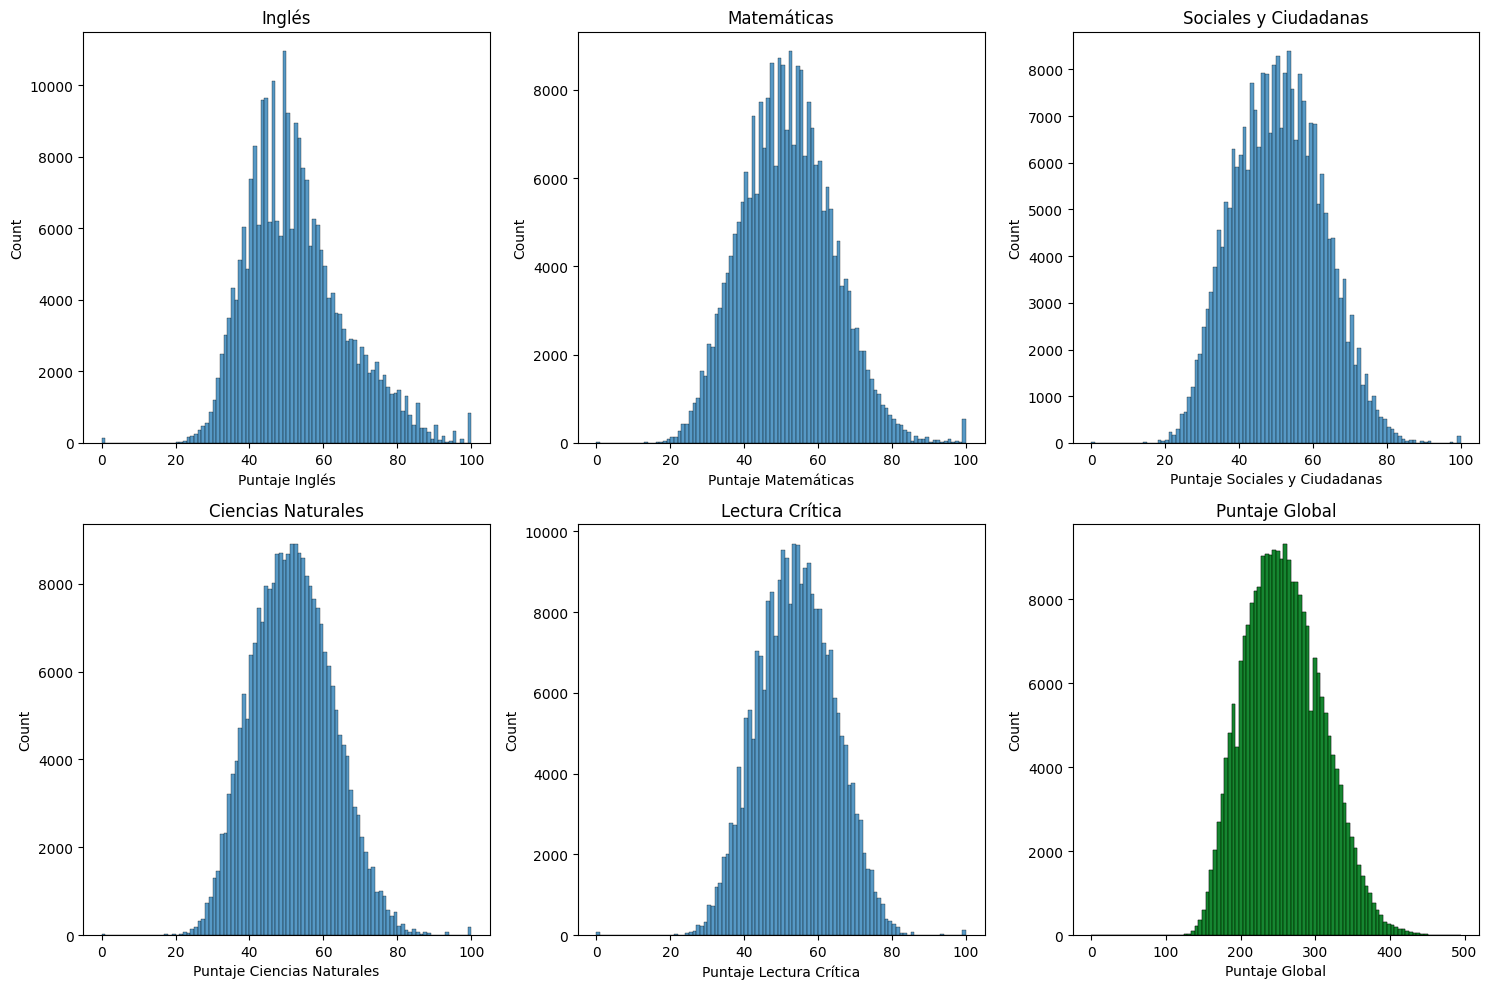

In [84]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(df[puntajes[i]], bins=100, ax=axes[i])
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")

sns.histplot(df[puntajes[5]], bins=100, ax=axes[5], color="green")
plt.tight_layout()
plt.show()

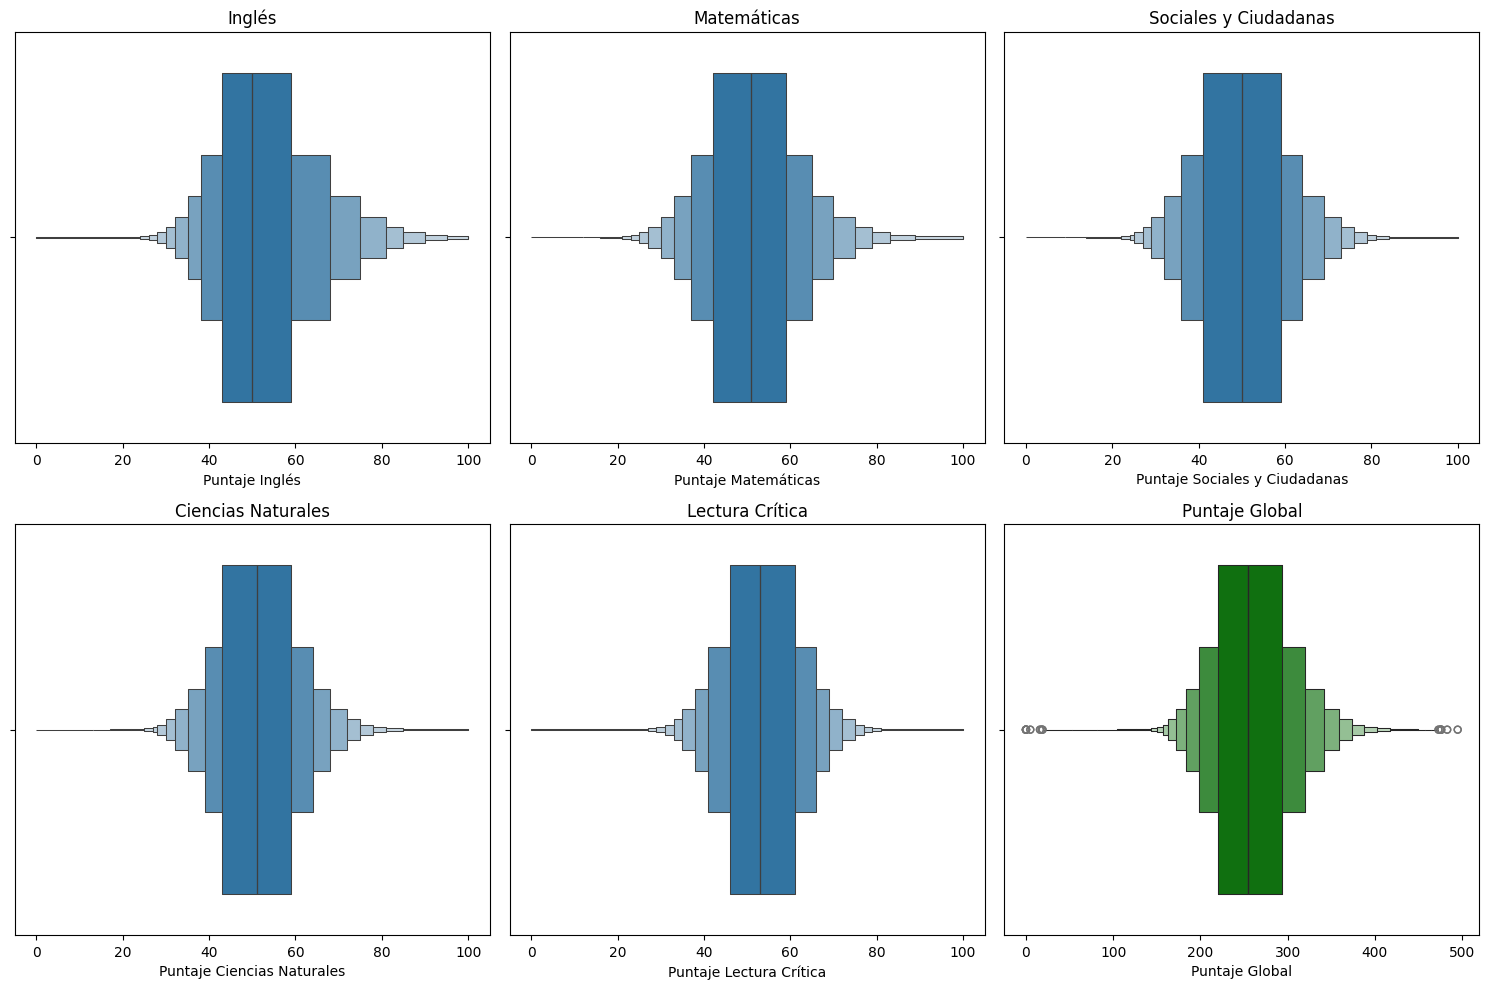

In [85]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.boxenplot(x=df[puntajes[i]], ax=axes[i])
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")

sns.boxenplot(x=df[puntajes[5]], ax=axes[5], color="green")
plt.tight_layout()
plt.show()

### Distribución de Estratos


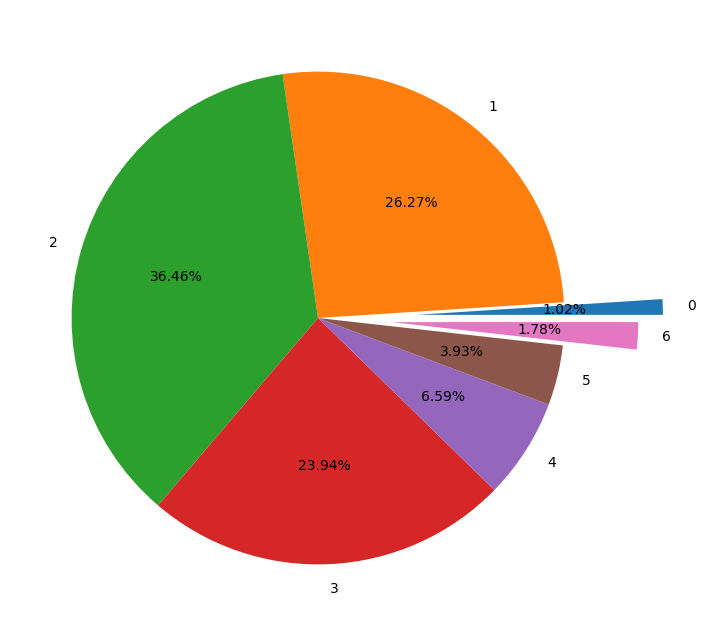

             Cantidad Porcentaje
estrato_num                     
0                2589    1.0192%
1               66740    26.274%
2               92626   36.4648%
3               60817   23.9423%
4               16747    6.5929%
5                9981    3.9293%
6                4515    1.7775%


In [86]:
cuantas = df["estrato_num"].value_counts().sort_index().to_frame(name="Cantidad")

explode = (0.4, 0, 0, 0, 0, 0, 0.3)

cuantas["Porcentaje"] = (cuantas["Cantidad"] / cuantas["Cantidad"].sum() * 100).round(4).astype(str) + "%"

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(cuantas["Cantidad"], labels=cuantas.index, autopct="%.2f%%", explode=explode)
plt.show()

print(cuantas)

### Personas en el hogar

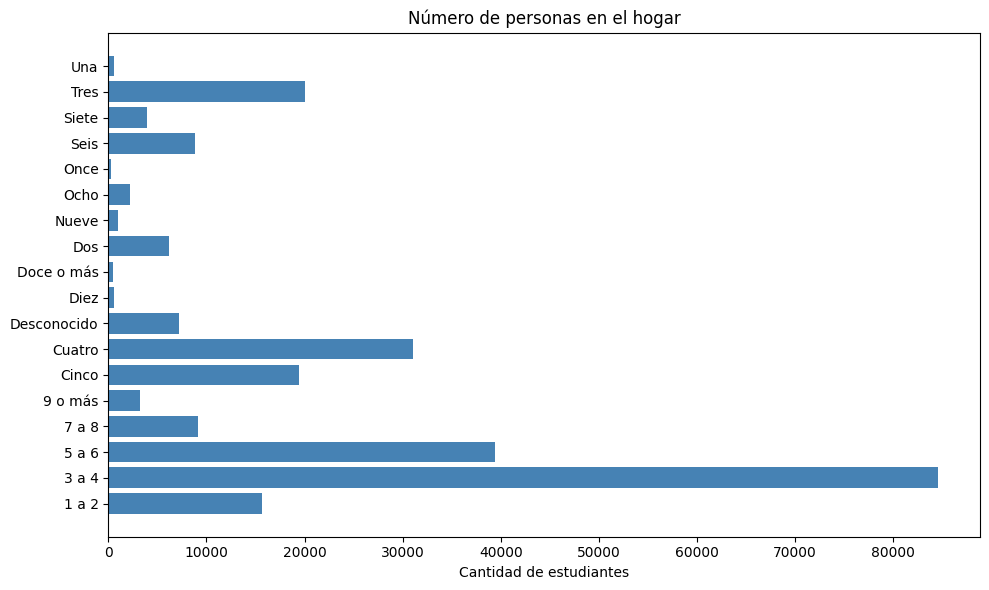

                    Personas Porcentaje
fami_personashogar                     
1 a 2                  15706    6.1831%
3 a 4                  84628   33.3161%
5 a 6                  39381   15.5034%
7 a 8                   9141    3.5986%
9 o más                 3236    1.2739%
Cinco                  19468    7.6641%
Cuatro                 31108   12.2465%
Desconocido             7175    2.8246%
Diez                     622    0.2449%
Doce o más               480     0.189%
Dos                     6149    2.4207%
Nueve                    967    0.3807%
Ocho                    2214    0.8716%
Once                     299    0.1177%
Seis                    8795    3.4624%
Siete                   3991    1.5712%
Tres                   20053    7.8944%
Una                      602     0.237%


In [87]:
fig, ax = plt.subplots(figsize=(10,6))

personas = df["fami_personashogar"].value_counts().sort_index().to_frame(name="Personas")
personas["Porcentaje"] = (personas["Personas"] / personas["Personas"].sum() * 100).round(4).astype(str) + "%"
labels = personas.index
valores = personas["Personas"]

bar_pos = range(len(labels))

ax.barh(bar_pos, valores, color="steelblue")

ax.set_yticks(bar_pos, labels)
ax.set_xlabel("Cantidad de estudiantes")
ax.set_title("Número de personas en el hogar")

plt.tight_layout()
plt.show()

print(personas)

### Presentaron en un departamento diferente al Valle


In [88]:

df[df["estu_cod_depto_presentacion"]!=76]
df[df["estu_depto_presentacion"]!="VALLE"] 

df[df["estu_cod_depto_presentacion"]!=76]["estu_depto_presentacion"].value_counts()


estu_depto_presentacion
RISARALDA          211
BOGOTÁ             174
CAUCA              130
CALDAS             115
ANTIOQUIA          107
CASANARE            83
CUNDINAMARCA        65
QUINDIO             62
META                48
TOLIMA              44
NARIÑO              41
HUILA               35
CAQUETA             22
SANTANDER           22
BOYACA              20
SAN ANDRES          20
ATLANTICO           13
VICHADA             11
BOLIVAR             11
ARAUCA              11
CHOCO                8
PUTUMAYO             7
CESAR                6
MAGDALENA            5
SUCRE                4
NORTE SANTANDER      3
CORDOBA              3
GUAVIARE             1
LA GUAJIRA           1
Name: count, dtype: int64

### Viven en un departamento diferente al Valle

In [89]:


df[df["estu_cod_reside_depto"]!=76]

df[df["estu_depto_reside"]!="VALLE"]["estu_depto_reside"].value_counts()



estu_depto_reside
CAUCA              273
BOGOTÁ             174
CALDAS             158
RISARALDA           62
CUNDINAMARCA        52
ANTIOQUIA           47
NARIÑO              43
QUINDIO             28
SANTANDER           20
TOLIMA              17
ATLANTICO           14
BOYACA              12
CHOCO               12
HUILA               11
BOLIVAR              9
META                 8
CASANARE             6
PUTUMAYO             5
CESAR                5
MAGDALENA            5
CAQUETA              5
NORTE SANTANDER      3
CORDOBA              2
GUAVIARE             1
SAN ANDRES           1
AMAZONAS             1
SUCRE                1
Name: count, dtype: int64

### Nacionalidades

In [90]:
df["estu_nacionalidad"].value_counts()





estu_nacionalidad
COLOMBIA                  253102
VENEZUELA                    630
ESTADOS UNIDOS                72
ESPAÑA                        54
ECUADOR                       34
FRANCIA                       10
ITALIA                        10
MÉXICO                         9
REINO UNIDO                    8
COSTA RICA                     8
PERÚ                           7
ARGENTINA                      7
NICARAGUA                      5
CHILE                          5
CUBA                           5
PAÍSES BAJOS - HOLANDA         4
HONDURAS                       3
COMORAS                        3
ARUBA                          3
PANAMÁ                         3
JAPÓN                          3
BRASIL                         3
VANUATU                        2
PORTUGAL                       2
GUATEMALA                      2
CANADÁ                         2
AUSTRALIA                      2
BRUNÉI                         2
OMÁN                           1
COSTA DE MARFIL          

Todos viven en el mismo pais en que residen

In [91]:
df[df["estu_nacionalidad"]!=df["estu_pais_reside"]]

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num,año


In [92]:
df[df["estu_nacionalidad"]!="COLOMBIA"]["estu_depto_reside"].value_counts()




estu_depto_reside
VALLE      912
BOLIVAR      1
Name: count, dtype: int64

# Outliers


In [93]:
df.kurt(numeric_only=True)
puntajes=["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]
for i in puntajes:
    
    print(pd.cut(df[i], bins=10).value_counts().sort_index())


punt_ingles
(-0.1, 10.0]       137
(10.0, 20.0]        54
(20.0, 30.0]      4133
(30.0, 40.0]     42538
(40.0, 50.0]     82057
(50.0, 60.0]     66676
(60.0, 70.0]     32223
(70.0, 80.0]     18163
(80.0, 90.0]      6389
(90.0, 100.0]     1645
Name: count, dtype: int64
punt_matematicas
(-0.1, 10.0]        28
(10.0, 20.0]       338
(20.0, 30.0]      9315
(30.0, 40.0]     41202
(40.0, 50.0]     73017
(50.0, 60.0]     73755
(60.0, 70.0]     41075
(70.0, 80.0]     12420
(80.0, 90.0]      1928
(90.0, 100.0]      937
Name: count, dtype: int64
punt_sociales_ciudadanas
(-0.1, 10.0]        39
(10.0, 20.0]       195
(20.0, 30.0]     10348
(30.0, 40.0]     47202
(40.0, 50.0]     72628
(50.0, 60.0]     72147
(60.0, 70.0]     39780
(70.0, 80.0]     10443
(80.0, 90.0]       993
(90.0, 100.0]      240
Name: count, dtype: int64
punt_c_naturales
(-0.1, 10.0]        28
(10.0, 20.0]       101
(20.0, 30.0]      4078
(30.0, 40.0]     38457
(40.0, 50.0]     79649
(50.0, 60.0]     79883
(60.0, 70.0]     41114


In [94]:
for i in puntajes:
    print(df[i].describe())

count    254015.000000
mean         52.125989
std          13.180788
min           0.000000
25%          43.000000
50%          50.000000
75%          59.000000
max         100.000000
Name: punt_ingles, dtype: float64
count    254015.000000
mean         51.250765
std          12.301105
min           0.000000
25%          42.000000
50%          51.000000
75%          59.000000
max         100.000000
Name: punt_matematicas, dtype: float64
count    254015.000000
mean         50.260615
std          11.962517
min           0.000000
25%          41.000000
50%          50.000000
75%          59.000000
max         100.000000
Name: punt_sociales_ciudadanas, dtype: float64
count    254015.000000
mean         51.338437
std          10.885795
min           0.000000
25%          43.000000
50%          51.000000
75%          59.000000
max         100.000000
Name: punt_c_naturales, dtype: float64
count    254015.000000
mean         53.505324
std          10.305067
min           0.000000
25%          

In [95]:
colegios=df.groupby("cole_nombre_establecimiento", as_index=False)[puntajes].mean()

top10_por_categoria = {p: colegios.sort_values(by=p, ascending=False)[["cole_nombre_establecimiento", p]].head(10)for p in puntajes}

for p, tabla in top10_por_categoria.items():
    print(f"\nTop 10 - {p}")
    print(tabla.to_string(index=False))


Top 10 - punt_ingles
          cole_nombre_establecimiento  punt_ingles
                          COL BOLIVAR    86.830870
          COLEGIO BILINGUE DIANA OESE    86.276968
            COLEGIO COLOMBO BRITÁNICO    85.599064
           COLEGIO GIMNASIO LA COLINA    84.764706
                        COL JEFFERSON    84.296935
                      COLEGIO BENNETT    83.302564
   COLEGIO PHILADELPHIA INTERNACIONAL    82.866438
                  ASPAEN LICEO TACURÍ    82.304878
COLEGIO INTERNACIONAL LOS CAÑAVERALES    81.432203
                      COLEGIO FREINET    81.327027

Top 10 - punt_matematicas
        cole_nombre_establecimiento  punt_matematicas
        COLEGIO BILINGUE DIANA OESE         82.125364
 COLEGIO PHILADELPHIA INTERNACIONAL         76.171233
           COLEGIO HISPANOAMERICANO         76.037500
                ASPAEN LICEO TACURÍ         72.530488
          COLEGIO COLOMBO BRITÁNICO         72.313573
                        COL BOLIVAR         72.224959
         COL

## Aberrantes

In [96]:
for i in puntajes:
    #print(df[i].value_counts().sort_index(ascending=True))
    print(f"Variable: {i}")
    print(df[i].unique()[:500])
#df["punt_global"].unique()[:500]

Variable: punt_ingles
[ 54.  44.  64.  46.  39.  50.  52.  49.  40.  38.  48.  35.  34.  53.
  63.  36.  51.  33.  55.  47.  42.  59.  58.  41.  67.  45.  32.  57.
  62.  60.  37. 100.  70.  65.  66.  43.  56.  73.  79.  74.  31.  29.
  68.  30.  75.  69.  76.  82.  61.  72.  71.  77.  78.  81.  83.  28.
  80.  94.  86.  85.  27.  95.  26.  84.  87.  88.  97.  22.   0.  24.
  23.  92.  14.  89.  90.  99.  25.  91.  20.  21.  93.  18.  98.   7.
  19.  96.  16.  13.  15.]
Variable: punt_matematicas
[ 48.  52.  54.  43.  19.  45.  61.  57.  28.  35.  37.  51.  64.  49.
  56.  30.  46.  42.  53.  40.  41.  38.  50.  39.  47.  60.  72.  59.
  32.  71.  24.  36.  62.  69.  65.  63.  34.  33.  70.  31.  55.  58.
  66.  68.  44.  21.  25.  23.  29.  67. 100.  26.  79.  76.  75.  27.
  20.  78.  77.  74.  80.  73.  17.  22.  92.  83.   0.  81.  82.  86.
  84.  87.  99.  88.  95.  89.  18.  91.  90.  98.  16.  96.  85.  15.
  12.  93.  97.  94.   7.   8.  13.  11.  10.]
Variable: punt_sociales_c

In [97]:
categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)

for i in categorias:
    #print(df[i].value_counts().sort_index(ascending=True))
    print(f"Variable: {i}")
    print(df[i].unique()[:1000])



Variable: periodo
[20224 20162 20194 20211 20172 20161 20181 20152 20201 20191 20171 20151
 20221]
Variable: estu_tipodocumento
['TI' 'CC' 'NES' 'CE' 'CR' 'PEP' 'PPT' 'PE' 'PC' 'RC' 'PET']
Variable: estu_consecutivo
['SB11202240052447' 'SB11202240057782' 'SB11202240151458'
 'SB11202240225511' 'SB11202240427250' 'SB11202240085624'
 'SB11202240282733' 'SB11202240167237' 'SB11202240080544'
 'SB11202240358675' 'SB11202240306684' 'SB11202240255965'
 'SB11202240112660' 'SB11202240554247' 'SB11202240191367'
 'SB11202240174269' 'SB11202240099983' 'SB11202240053763'
 'SB11202240576774' 'SB11202240138462' 'SB11202240071927'
 'SB11202240110551' 'SB11202240222637' 'SB11202240163311'
 'SB11202240169017' 'SB11202240196630' 'SB11202240248601'
 'SB11202240231569' 'SB11202240168171' 'SB11202240191933'
 'SB11202240292156' 'SB11202240224472' 'SB11202240083784'
 'SB11202240524158' 'SB11202240562428' 'SB11202240320785'
 'SB11202240103973' 'SB11202240516890' 'SB11202240255237'
 'SB11202240018715' 'SB1120224

C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_17880\3821789596.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_17880\3821789596.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

['URBANO' 'RURAL']
Variable: cole_bilingue
['Desconocido' 'N' 'S']
Variable: cole_calendario
['A' 'B' 'OTRO']
Variable: cole_caracter
['Desconocido' 'TÉCNICO/ACADÉMICO' 'ACADÉMICO' 'TÉCNICO' 'NO APLICA']
Variable: cole_cod_dane_establecimiento
['URBANO' 'RURAL']
Variable: cole_cod_dane_sede
[1.76001800e+11 1.76111001e+11 1.76364001e+11 1.76606000e+11
 3.76001043e+11 1.76109002e+11 1.76126000e+11 1.76892000e+11
 1.76130000e+11 1.76001002e+11 1.76834004e+11 3.76001001e+11
 2.76892000e+11 3.76109016e+11 2.76834001e+11 1.76001800e+11
 1.76520000e+11 3.76001037e+11 1.76147000e+11 2.76828000e+11
 1.76111001e+11 1.76001003e+11 3.76233001e+11 1.76248000e+11
 1.76109000e+11 1.76020000e+11 1.76001006e+11 1.76520000e+11
 2.76892000e+11 1.76109001e+11 4.76001043e+11 1.76834000e+11
 3.76001038e+11 3.76001001e+11 1.76001002e+11 3.76001034e+11
 1.76147002e+11 1.76001040e+11 1.76520002e+11 3.76001038e+11
 1.76001002e+11 3.76001001e+11 1.76892000e+11 1.76109000e+11
 3.76001041e+11 1.76109003e+11 1.7610

In [98]:
print(df[df["cole_mcpio_ubicacion"]=="CALIMA"]["año"].value_counts())


Series([], Name: count, dtype: int64)
